# Figure 5 reproduction: JMP-style TensorFlow neural networks

This notebook reproduces Figure 5 from the main article:

> Vallerio, M., del Rio Chanona, A., & Navarro-Brull, F. J. (2026). *All you need is noise - from feature selection to explainable industrial AI*. **Digital Chemical Engineering, 18**, 100290.

The article's central supervised-learning idea is to add synthetic-noise features (SNFs) to the modeling table and then inspect whether a model uses them. If a real process variable is less influential than random noise, or if the prediction profiler responds to random noise, the model is using capacity on structure that cannot be physically meaningful.

Figure 5 applies that idea to an artificial neural network (ANN). The first ANN is intentionally too flexible. Its profiler responds to `Random Normal Noise`, which indicates over-parameterization. The second ANN is compressed. The target is not maximum apparent fit; the target is a model whose profiler still responds to meaningful process inputs but is almost flat for the SNF.

The corrected Figure 5 setup is:

- Inputs: `Difference[PressureC1]`, `FlowC1`, `Temp1`, and `Random Normal Noise`
- Output: `yield`
- Panel 5a: two hidden layers with 5 sigmoid-like activation functions each
- Panel 5b: one hidden layer with 3 sigmoid-like activation functions
- Panels 5c and 5d: prediction-profiler / partial-dependence plots for each input

JMP's Neural documentation describes TanH as a sigmoid activation function and describes the `Squared` penalty as a sum of squared parameters. The TensorFlow implementation below therefore uses `activation="tanh"` hidden nodes and L2 regularization as the squared penalty analogue.


In [1]:
# Dependency bootstrap.
# The notebook is intended to be runnable from the workbook alone, so it checks
# for the small Python stack it needs before the analysis begins.
import importlib.util
import subprocess
import sys


def ensure(import_name, package_name=None):
    # Some packages have a different pip package name from their import name.
    package_name = package_name or import_name
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


for import_name, package_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("openpyxl", "openpyxl"),
    ("matplotlib", "matplotlib"),
    ("sklearn", "scikit-learn"),
    ("tensorflow", "tensorflow"),
]:
    ensure(import_name, package_name)

print("Dependencies are available.")


Dependencies are available.


In [2]:
from pathlib import Path
import os
import warnings

# Keep TensorFlow startup logs out of the rendered paper-style notebook.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras


# Consistent plotting defaults for the rendered HTML and saved PNG.
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 9,
})

ROOT = Path("/Users/b42549592/Documents/GitHub/all-you-need-is-noise/01_supervised")
DATA_PATH = ROOT / "distillation_tower_noise_paper.xlsx"
OUTPUT_DIR = ROOT / "results" / "python" / "neural_networks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load the attached distillation tower workbook used by the supervised section.
raw = pd.read_excel(DATA_PATH, sheet_name="distillation_tower_noise_paper")
raw.shape


(253, 86)

## Data

Figure 5 uses four inputs: three process-derived inputs and one synthetic-noise feature. The pressure term is the row-to-row pressure change, not the absolute column pressure. The first row has no previous pressure value, so `Difference[PressureC1]` is missing there and is dropped. That leaves 252 observations for the Figure 5 reproduction.

The features are standardized before fitting because neural-network optimization is sensitive to variable scale. The target is standardized for training and then transformed back to yield units for metrics and profilers.


In [3]:
# Use exactly the Figure 5 inputs, in the order shown in the paper-style panel.
features = ["Difference[PressureC1]", "FlowC1", "Temp1", "Random Normal Noise"]
target = "yield"

# Drop the first row with missing pressure difference and keep only the model columns.
data = raw[features + [target]].dropna().copy()
X = data[features].astype(float).to_numpy()
y = data[target].astype(float).to_numpy()

# Scale inputs and target for stable gradient-based optimization.
# Predictions are converted back to yield units after training.
x_scaler = StandardScaler().fit(X)
y_scaler = StandardScaler().fit(y.reshape(-1, 1))
X_scaled = x_scaler.transform(X)
y_scaled = y_scaler.transform(y.reshape(-1, 1)).ravel()

print(f"Rows used: {len(data)}")
display(data[features + [target]].head())


Rows used: 252


,Difference[PressureC1],FlowC1,Temp1,Random Normal Noise,yield
1,-9.9628,487.4029,131.0470,-0.161520,66.532666
2,-0.0695,437.3516,118.2666,0.443886,71.102193
3,0.2257,481.8314,118.1769,-0.854174,69.793481
4,-0.1678,412.6471,120.7891,-1.971986,71.489516
5,-1.2641,470.8127,121.7929,-1.092581,69.055089


## TensorFlow approximation of JMP Neural

JMP's Neural platform fits penalized neural networks. The relevant default penalty family here is squared parameter penalty, which is the same practical regularization idea as L2 weight decay in TensorFlow.

JMP tunes its penalty internally with validation. To keep this notebook deterministic and simple, the squared penalties below are fixed after calibration to match the Figure 5 behavior:

- the 5 + 5 model retains enough flexibility to respond to `Random Normal Noise`;
- the 3-node model is compressed enough that the `Random Normal Noise` profiler is nearly flat.

This is a behavioral reproduction of the figure, not an attempt to duplicate JMP's optimizer byte-for-byte.


In [4]:
def fit_ann(name, hidden_layers, l2_penalty, epochs, seed, learning_rate=0.01):
    # Reset Keras state and random seeds so reruns give the same trained network.
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    # JMP's squared parameter penalty is represented here with L2 penalties on
    # both weights and biases. The L2 values are fixed to reproduce the figure's
    # overfit-versus-compressed behavior.
    regularizer = keras.regularizers.l2(l2_penalty)

    # Build a fully connected feed-forward ANN. TanH is the sigmoid-like
    # activation used to approximate JMP's TanH sigmoid hidden units.
    model = keras.Sequential([keras.Input(shape=(X_scaled.shape[1],))])
    for units in hidden_layers:
        model.add(
            keras.layers.Dense(
                units,
                activation="tanh",
                kernel_regularizer=regularizer,
                bias_regularizer=regularizer,
            )
        )

    # Linear output node because yield is a continuous regression target.
    model.add(
        keras.layers.Dense(
            1,
            kernel_regularizer=regularizer,
            bias_regularizer=regularizer,
        )
    )

    # Mean squared error matches the continuous-yield regression objective.
    model.compile(optimizer=keras.optimizers.Adam(learning_rate), loss="mse")
    history = model.fit(X_scaled, y_scaled, epochs=epochs, verbose=0)

    # Convert predictions back to original yield units before reporting metrics.
    pred = y_scaler.inverse_transform(model.predict(X_scaled, verbose=0)).ravel()
    metrics = {
        "model": name,
        "hidden_layers": " + ".join(map(str, hidden_layers)),
        "activation": "tanh sigmoid",
        "squared_l2_penalty": l2_penalty,
        "epochs": epochs,
        "R2": r2_score(y, pred),
        "RMSE": mean_squared_error(y, pred) ** 0.5,
    }
    return model, history, pred, metrics


oversized_model, oversized_history, oversized_pred, oversized_metrics = fit_ann(
    # Panel 5a: intentionally over-sized network, two hidden layers of 5 nodes.
    name="5a Oversized ANN",
    hidden_layers=(5, 5),
    l2_penalty=0.007,
    epochs=200,
    seed=7,
)

compact_model, compact_history, compact_pred, compact_metrics = fit_ann(
    # Panel 5b: compressed network, one hidden layer of 3 nodes.
    name="5b Compact ANN",
    hidden_layers=(3,),
    l2_penalty=0.003,
    epochs=300,
    seed=2,
    learning_rate=0.005,
)

metrics = pd.DataFrame([oversized_metrics, compact_metrics])
metrics.to_csv(OUTPUT_DIR / "figure5_tensorflow_ann_metrics.csv", index=False)
metrics


,model,hidden_layers,activation,squared_l2_penalty,epochs,R2,RMSE
0,5a Oversized ANN,5 + 5,tanh sigmoid,0.007,200,0.845915,0.528305
1,5b Compact ANN,3,tanh sigmoid,0.003,300,0.619433,0.830273


## Partial-dependence / prediction profiler

Each profiler line varies one input across its observed 5th-to-95th percentile range while averaging model predictions over all rows. This is the partial-dependence version of JMP's profiler: flat response to `Random Normal Noise` means the network is not using synthetic noise to explain yield.

The key diagnostic is the relative shape of the curves, not the exact axis range. Process variables should produce structured changes in predicted yield. The synthetic noise curve should be flat after the network is simplified.


In [5]:
def predict_yield(model, X_original):
    # Apply the same input scaling used during training, then invert target scaling.
    pred_scaled = model.predict(x_scaler.transform(X_original), verbose=0).ravel()
    return y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()


def pdp_for_model(model, n_grid=41):
    # A PDP point is computed by replacing one column with a fixed grid value,
    # predicting every row, and averaging those predictions.
    rows = []
    for feature_index, feature_name in enumerate(features):
        # Use the central observed range to avoid extrapolating beyond the data.
        grid = np.linspace(
            np.quantile(X[:, feature_index], 0.05),
            np.quantile(X[:, feature_index], 0.95),
            n_grid,
        )
        for value in grid:
            X_grid = X.copy()
            X_grid[:, feature_index] = value
            # Store one averaged predicted-yield value per feature-grid setting.
            rows.append({
                "feature": feature_name,
                "value": value,
                "partial_dependence": predict_yield(model, X_grid).mean(),
            })
    return pd.DataFrame(rows)


oversized_pdp = pdp_for_model(oversized_model)
compact_pdp = pdp_for_model(compact_model)

# Summarize how much each profiler moves. The SNF span is the compact diagnostic
# used to compare whether random noise is still affecting model predictions.
pdp_summary = pd.concat([
    oversized_pdp.assign(model="5a Oversized ANN"),
    compact_pdp.assign(model="5b Compact ANN"),
]).groupby(["model", "feature"])["partial_dependence"].agg(
    pdp_min="min", pdp_max="max"
).reset_index()
pdp_summary["pdp_span"] = pdp_summary["pdp_max"] - pdp_summary["pdp_min"]
pdp_summary.to_csv(OUTPUT_DIR / "figure5_pdp_spans.csv", index=False)
pdp_summary


,model,feature,pdp_min,pdp_max,pdp_span
0,5a Oversized ANN,Difference[PressureC1],68.195374,69.712143,1.516769
1,5a Oversized ANN,FlowC1,68.651741,70.339775,1.688034
2,5a Oversized ANN,Random Normal Noise,69.392982,69.469498,0.076515
3,5a Oversized ANN,Temp1,67.999741,69.944542,1.944801
4,5b Compact ANN,Difference[PressureC1],67.840691,69.701920,1.861229
5,5b Compact ANN,FlowC1,68.487976,70.035927,1.547951
6,5b Compact ANN,Random Normal Noise,69.409836,69.419899,0.010063
7,5b Compact ANN,Temp1,68.055031,69.717789,1.662758


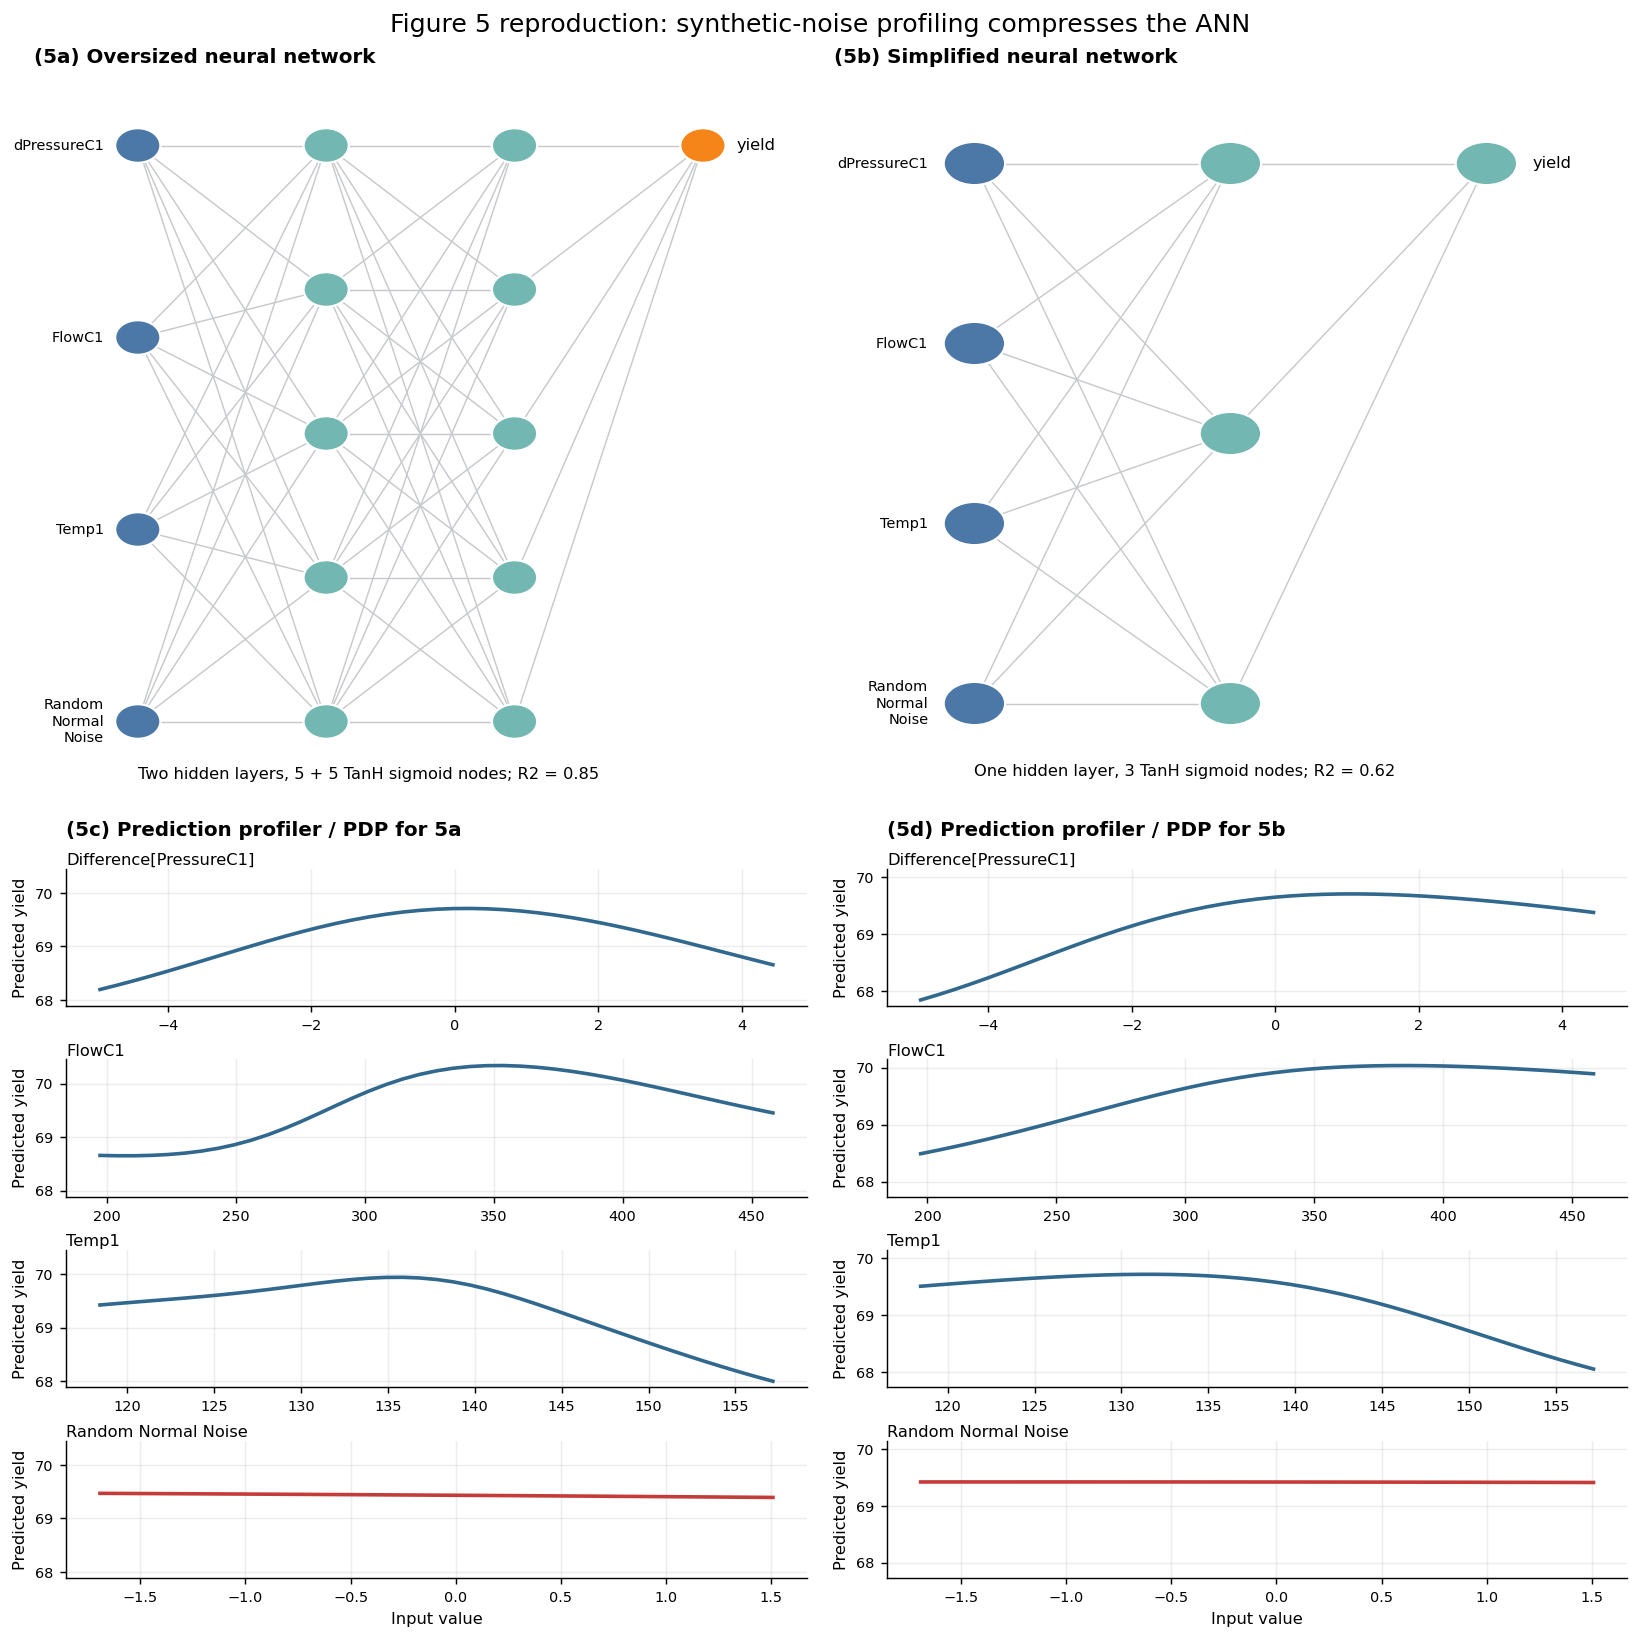

Saved figure to: /Users/b42549592/Documents/GitHub/all-you-need-is-noise/01_supervised/results/python/neural_networks/figure5_tensorflow_ann_pdp_reproduction.png


In [6]:
def draw_network(ax, layer_sizes, title, subtitle):
    # Draw a compact schematic of the neural-network architecture used in
    # the corresponding paper panel. It is illustrative rather than a weight plot.
    ax.set_title(title, loc="left", fontsize=11, fontweight="bold")
    ax.set_xlim(-0.55, len(layer_sizes) - 0.45)
    ax.set_ylim(-0.5, max(layer_sizes) - 0.5)
    ax.axis("off")

    xs = np.arange(len(layer_sizes))
    positions = []
    for x, size in zip(xs, layer_sizes):
        # Vertically center each layer so 5-node and 3-node networks are readable.
        y_positions = np.linspace(max(layer_sizes) - 1, 0, size)
        positions.append([(x, y) for y in y_positions])

    # Draw dense feed-forward connections between adjacent layers.
    for left, right in zip(positions[:-1], positions[1:]):
        for x0, y0 in left:
            for x1, y1 in right:
                ax.plot([x0, x1], [y0, y1], color="#C7C9CC", lw=0.8, zorder=1)

    colors = ["#4C78A8", "#72B7B2", "#72B7B2", "#F58518"]
    for layer_idx, layer in enumerate(positions):
        for node_idx, (x, y_pos) in enumerate(layer):
            circle = Circle((x, y_pos), 0.12, facecolor=colors[min(layer_idx, len(colors) - 1)], edgecolor="white", lw=1.2, zorder=2)
            ax.add_patch(circle)
            if layer_idx == 0:
                label = ["dPressureC1", "FlowC1", "Temp1", "Random\nNormal\nNoise"][node_idx]
                ax.text(x - 0.18, y_pos, label, ha="right", va="center", fontsize=8)
            elif layer_idx == len(positions) - 1:
                ax.text(x + 0.18, y_pos, "yield", ha="left", va="center", fontsize=9)

    ax.text(0, -0.42, subtitle, ha="left", va="bottom", fontsize=9)


def plot_profiler_grid(axs, pdp, title, highlight_noise=True):
    # Use one row per input so each profiler has the same size and scale.
    for ax, feature in zip(axs, features):
        sub = pdp[pdp["feature"] == feature]
        is_noise = feature == "Random Normal Noise"
        color = "#C43C39" if is_noise and highlight_noise else "#31688E"
        ax.plot(sub["value"], sub["partial_dependence"], color=color, lw=2)
        ax.set_title(feature, loc="left", fontsize=9, pad=2)
        ax.set_ylabel("Predicted yield")
        ax.tick_params(labelsize=8)
    axs[0].text(0, 1.24, title, transform=axs[0].transAxes, fontsize=11, fontweight="bold", ha="left")
    axs[-1].set_xlabel("Input value")


# Two architecture panels on top, two four-row profiler panels below.
fig = plt.figure(figsize=(12.5, 12.5), constrained_layout=True)
subfigs = fig.subfigures(2, 2, height_ratios=[1.0, 1.08])

ax_5a = subfigs[0, 0].subplots(1, 1)
draw_network(
    ax_5a,
    [4, 5, 5, 1],
    "(5a) Oversized neural network",
    f"Two hidden layers, 5 + 5 TanH sigmoid nodes; R2 = {oversized_metrics['R2']:.2f}",
)

ax_5b = subfigs[0, 1].subplots(1, 1)
draw_network(
    ax_5b,
    [4, 3, 1],
    "(5b) Simplified neural network",
    f"One hidden layer, 3 TanH sigmoid nodes; R2 = {compact_metrics['R2']:.2f}",
)

axs_5c = subfigs[1, 0].subplots(4, 1, sharey=True)
plot_profiler_grid(axs_5c, oversized_pdp, "(5c) Prediction profiler / PDP for 5a")

axs_5d = subfigs[1, 1].subplots(4, 1, sharey=True)
plot_profiler_grid(axs_5d, compact_pdp, "(5d) Prediction profiler / PDP for 5b")

fig.suptitle("Figure 5 reproduction: synthetic-noise profiling compresses the ANN", fontsize=14)
figure_path = OUTPUT_DIR / "figure5_tensorflow_ann_pdp_reproduction.png"
fig.savefig(figure_path, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {figure_path}")


**Figure 5. Synthetic-noise profiling for ANN compression.** Panel 5a shows an over-sized neural network with two hidden layers of five TanH sigmoid nodes. Panel 5c shows its partial-dependence profilers: the `Random Normal Noise` curve is not perfectly flat, indicating that the network still assigns some predictive structure to synthetic noise. Panel 5b shows the simplified one-hidden-layer network with three TanH sigmoid nodes. Panel 5d shows the corresponding profiler after compression; the process inputs retain structured response curves, while the random-noise curve is effectively flat. This reproduces the article's point that synthetic-noise features can guide ANN simplification.


In [7]:
# Report the numerical checks used in the caption: model fit and SNF profiler span.
noise_spans = pdp_summary[pdp_summary["feature"] == "Random Normal Noise"][["model", "pdp_span"]]
display(metrics)
display(noise_spans)


,model,hidden_layers,activation,squared_l2_penalty,epochs,R2,RMSE
0,5a Oversized ANN,5 + 5,tanh sigmoid,0.007,200,0.845915,0.528305
1,5b Compact ANN,3,tanh sigmoid,0.003,300,0.619433,0.830273


,model,pdp_span
2,5a Oversized ANN,0.076515
6,5b Compact ANN,0.010063


## Reading the result

The oversized 5 + 5 network has a higher apparent fit and its `Random Normal Noise` profiler is visibly non-flat. The compressed 3-node network has an R² near the paper's reported simplified model and an almost flat synthetic-noise profiler. That is the Figure 5 diagnostic: use the SNF profiler to detect excess capacity, then simplify the neural network until the noise response disappears.
